In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка
df = pd.read_csv("../DataEnedis10_000/enedis_iris_data.csv")

# Очистка consommation
df = df[df['conso_totale_mwh'].notna()]
df['conso_totale_mwh'] = pd.to_numeric(df['conso_totale_mwh'], errors='coerce')


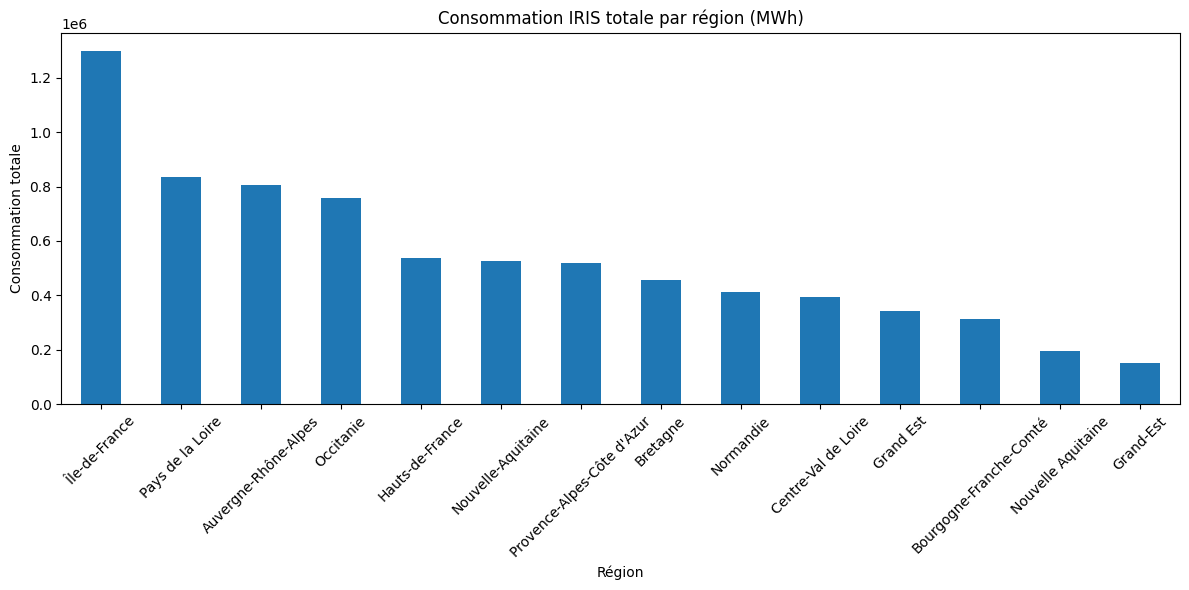

In [2]:
# === 1. Consommation totale par région ===
region_total = df.groupby('nom_region')['conso_totale_mwh'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
region_total.plot(kind='bar')
plt.title("Consommation IRIS totale par région (MWh)")
plt.xlabel("Région")
plt.ylabel("Consommation totale")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

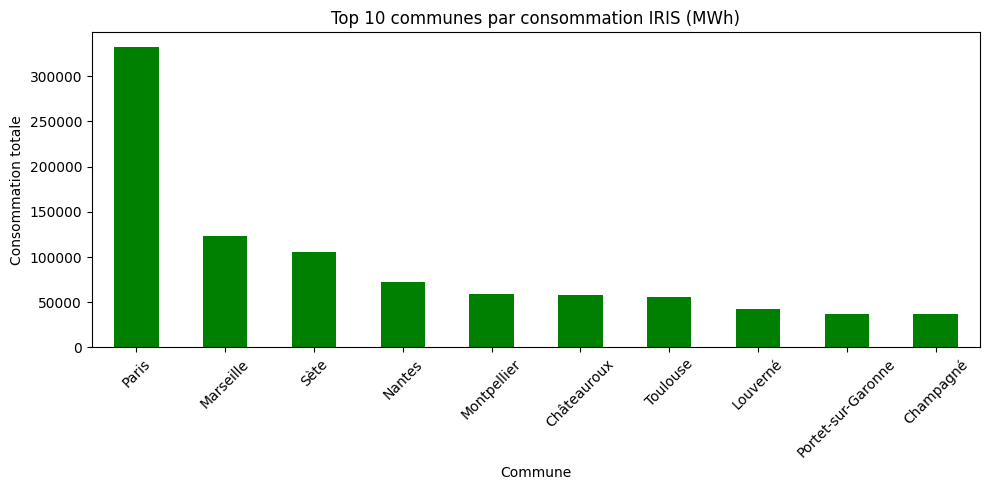

In [3]:
# === 2. Top 10 communes consommatrices ===
commune_top = df.groupby('nom_commune')['conso_totale_mwh'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
commune_top.plot(kind='bar', color='green')
plt.title("Top 10 communes par consommation IRIS (MWh)")
plt.xlabel("Commune")
plt.ylabel("Consommation totale")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

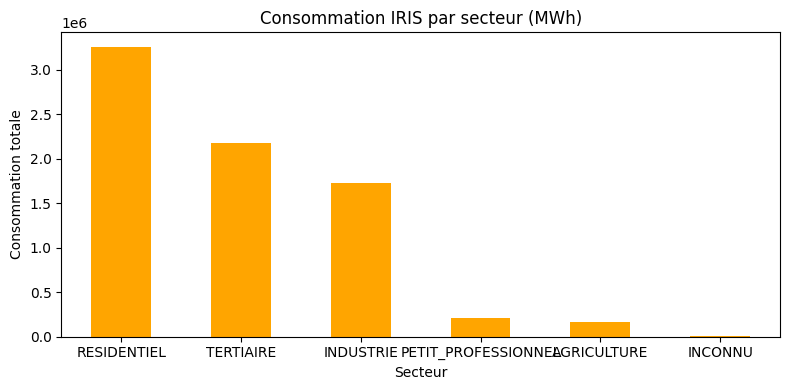

In [4]:
# === 3. Consommation par secteur (code_grand_secteur) ===
secteur_total = df.groupby('code_grand_secteur')['conso_totale_mwh'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
secteur_total.plot(kind='bar', color='orange')
plt.title("Consommation IRIS par secteur (MWh)")
plt.xlabel("Secteur")
plt.ylabel("Consommation totale")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

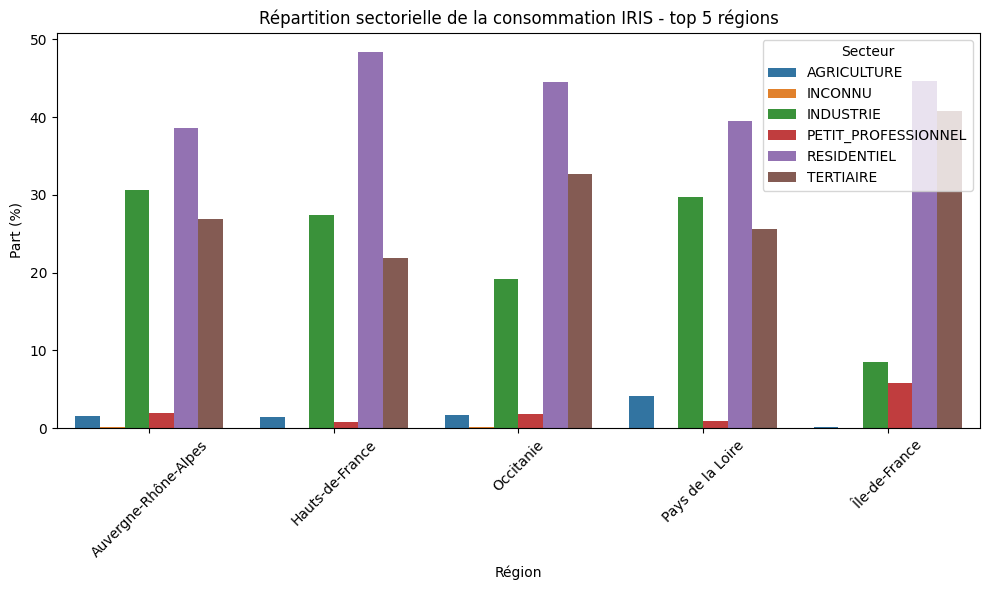

In [5]:
# === 4. Répartition secteur par région (pourcentage) ===
secteurs_region = df.groupby(['nom_region', 'code_grand_secteur'])['conso_totale_mwh'].sum().reset_index()
total_par_region = secteurs_region.groupby('nom_region')['conso_totale_mwh'].transform('sum')
secteurs_region['pourcentage'] = (secteurs_region['conso_totale_mwh'] / total_par_region) * 100
# Только для top 5 régions
top5 = secteurs_region[secteurs_region['nom_region'].isin(region_total.head(5).index)]

plt.figure(figsize=(10,6))
sns.barplot(data=top5, x='nom_region', y='pourcentage', hue='code_grand_secteur')
plt.title("Répartition sectorielle de la consommation IRIS - top 5 régions")
plt.ylabel("Part (%)")
plt.xlabel("Région")
plt.xticks(rotation=45)
plt.legend(title="Secteur")
plt.tight_layout()
plt.show()